<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-7/blob/main/Ejercicio1_Clustering_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 1: Clustering sobre el dataset Iris
**K-Means, DBSCAN y Spectral Clustering + métricas de validación interna y externa**

**Plan de trabajo**
1. Cargar y preparar los datos (estandarización de características)
2. K-Means: elegir *k* (método del codo + silhouette) y entrenar
3. DBSCAN: elegir `eps` y `min_samples` y entrenar
4. Spectral Clustering: entrenar con 3 grupos
5. Métricas de validación **interna** (sin etiquetas reales) y **externa** (comparando con las especies)
6. Comparación final y visualización en 2D con PCA

> **Idea clave:** el clustering es aprendizaje *no supervisado*, así que los modelos se entrenan **sin** las especies (`y`). Las especies solo se usan al final para la validación externa.

## 1. Carga y preparación de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,   # internas
    adjusted_rand_score, normalized_mutual_info_score, mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score             # externas
)

RANDOM_STATE = 42

In [2]:
iris = load_iris()
X = iris.data                      # 150 muestras x 4 características
y_true = iris.target               # SOLO para validación externa
species = pd.Series(iris.target_names[y_true], name="species")

print("Forma de X:", X.shape)
print("Características:", iris.feature_names)
pd.DataFrame(X, columns=iris.feature_names).describe().round(2)

Forma de X: (150, 4)
Características: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### Estandarización
Como muestran las diapositivas (dataset de vinos), los algoritmos de clustering son muy sensibles a la escala: la varianza de una característica equivale a su influencia. Estandarizamos con `StandardScaler` (media 0, varianza 1).

Varianza explicada por 2 componentes: 0.958


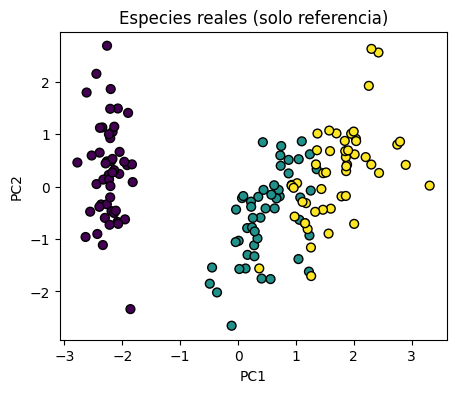

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2D solo para visualizar los resultados
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print("Varianza explicada por 2 componentes:", pca.explained_variance_ratio_.sum().round(3))

# Vista de las especies reales (referencia)
plt.figure(figsize=(5,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_true, cmap="viridis", edgecolor="k", s=40)
plt.title("Especies reales (solo referencia)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

## 2. K-Means

### 2.1 Elección de *k*: método del codo y silhouette

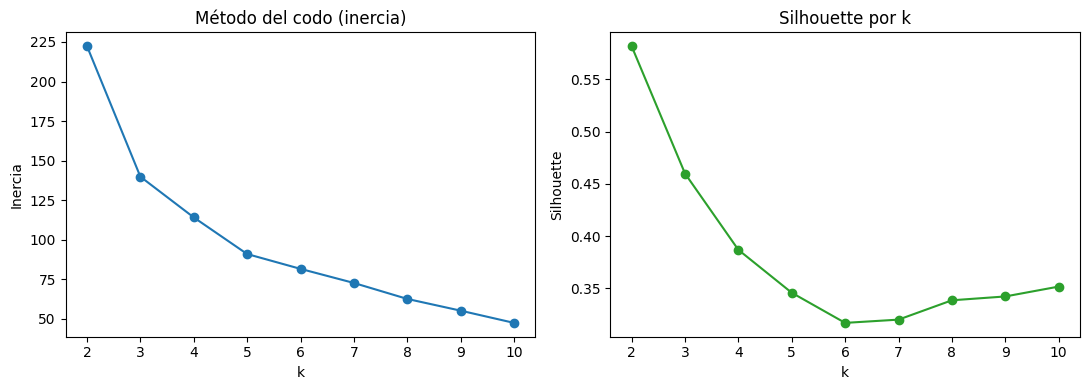

,k,inercia,silhouette
0,2,222.36,0.582
1,3,139.82,0.460
2,4,114.09,0.387
3,5,90.93,0.346
4,6,81.54,0.317
5,7,72.63,0.320
6,8,62.54,0.339
7,9,55.12,0.342
8,10,47.39,0.352


In [4]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Método del codo (inercia)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inercia")
ax[1].plot(list(ks), sils, "o-", color="tab:green"); ax[1].set_title("Silhouette por k")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

pd.DataFrame({"k": list(ks), "inercia": np.round(inertias,2), "silhouette": np.round(sils,3)})

**Lectura:** el silhouette suele ser máximo en *k = 2* (porque *versicolor* y *virginica* se solapan), mientras que el codo y el conocimiento del dominio (3 especies) sugieren *k = 3*. Usamos **k = 3** para poder comparar con las 3 especies reales.

In [5]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_km = kmeans.fit_predict(X_scaled)
print("Tamaño de cada cluster:", np.bincount(labels_km))
print("Inercia:", round(kmeans.inertia_, 2))

Tamaño de cada cluster: [53 50 47]
Inercia: 139.82


## 3. DBSCAN

DBSCAN no necesita el número de clusters, pero sí `eps` (radio del vecindario) y `min_samples`. Para elegir `eps` se usa el **gráfico de distancias al k-ésimo vecino**: se busca el "codo".

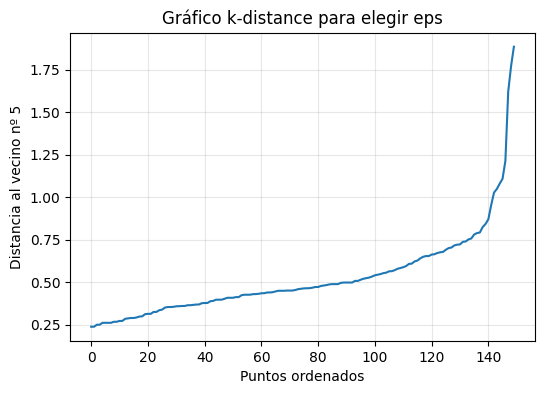

In [6]:
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
dist, _ = nn.kneighbors(X_scaled)
kdist = np.sort(dist[:, -1])

plt.figure(figsize=(6,4))
plt.plot(kdist)
plt.xlabel("Puntos ordenados"); plt.ylabel(f"Distancia al vecino nº {min_samples}")
plt.title("Gráfico k-distance para elegir eps"); plt.grid(alpha=.3); plt.show()

### Búsqueda de hiperparámetros (`eps`, `min_samples`)

In [7]:
def metricas_sin_ruido(X, labels):
    """Silhouette calculado solo con puntos que no son ruido (-1). Devuelve NaN si hay < 2 clusters."""
    mask = labels != -1
    if len(set(labels[mask])) < 2:
        return np.nan
    return silhouette_score(X[mask], labels[mask])

rows = []
for eps in np.arange(0.3, 1.21, 0.1):
    for ms in [3, 4, 5, 6, 8, 10]:
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        n_cl = len(set(lab)) - (1 if -1 in lab else 0)
        rows.append({"eps": round(eps,2), "min_samples": ms, "n_clusters": n_cl,
                     "ruido": int((lab == -1).sum()), "silhouette": metricas_sin_ruido(X_scaled, lab)})
grid = pd.DataFrame(rows)
grid.sort_values("silhouette", ascending=False).head(10)

,eps,min_samples,n_clusters,ruido,silhouette
17,0.5,10,3,89,0.710088
14,0.5,5,2,34,0.655889
13,0.5,4,2,33,0.655006
23,0.6,10,2,35,0.649523
22,0.6,8,2,32,0.648360
21,0.6,6,2,29,0.645786
20,0.6,5,2,26,0.641895
4,0.3,8,2,131,0.638720
2,0.3,5,3,120,0.630176
29,0.7,10,2,20,0.629096


El silhouette por sí solo puede premiar soluciones degeneradas (pocos puntos "core" y mucho ruido). Por eso elegimos la configuración de **mayor silhouette entre las que tienen al menos 2 clusters y como máximo 10 % de ruido**.

In [8]:
cand = grid[(grid.n_clusters >= 2) & (grid.ruido <= 0.10 * len(X_scaled))]
best = cand.sort_values("silhouette", ascending=False).iloc[0]
print(best)

dbscan = DBSCAN(eps=float(best.eps), min_samples=int(best.min_samples))
labels_db = dbscan.fit_predict(X_scaled)
print("\nClusters encontrados:", len(set(labels_db)) - (1 if -1 in labels_db else 0))
print("Puntos de ruido (-1):", (labels_db == -1).sum())
print("Tamaño por etiqueta:", {int(k): int(v) for k, v in zip(*np.unique(labels_db, return_counts=True))})

eps             0.700000
min_samples     6.000000
n_clusters      2.000000
ruido          12.000000
silhouette      0.617528
Name: 27, dtype: float64

Clusters encontrados: 2
Puntos de ruido (-1): 12
Tamaño por etiqueta: {-1: 12, 0: 47, 1: 91}


> **Nota:** en Iris, *versicolor* y *virginica* forman una nube continua sin una separación de densidad clara. Por eso DBSCAN tiende a encontrar 2 grupos (setosa vs. el resto) y/o a marcar puntos como ruido. Es una limitación esperada del algoritmo con este dataset, no un error.

## 4. Spectral Clustering

In [9]:
spectral = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",   # grafo de vecinos: permite fronteras no lineales
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=RANDOM_STATE
)
labels_sp = spectral.fit_predict(X_scaled)
print("Tamaño de cada cluster:", np.bincount(labels_sp))

Tamaño de cada cluster: [35 49 66]


## 5. Métricas de validación

**Validación interna** (solo usa los datos y las etiquetas de cluster, sin verdad fundamental):
- **Silhouette** (↑ mejor, rango −1 a 1): qué tan cerca está cada punto de su cluster frente a los demás.
- **Calinski-Harabasz** (↑ mejor): cociente entre dispersión entre clusters y dentro de clusters.
- **Davies-Bouldin** (↓ mejor): similitud media entre cada cluster y su más parecido.

**Validación externa** (compara con las especies reales):
- **ARI** – Adjusted Rand Index (↑, 1 = perfecto, ~0 = azar).
- **NMI** – Normalized Mutual Information (↑, 0 a 1) y **MI** (información mutua sin normalizar).
- **Homogeneidad** (cada cluster contiene una sola especie), **Completitud** (cada especie cae en un solo cluster) y **V-measure** (media armónica de ambas).

En DBSCAN, el ruido (`-1`) se **excluye** en las métricas internas (no es un cluster). En las externas se deja: cada punto de ruido cuenta como su propio "grupo" residual, lo que penaliza el resultado.

In [10]:
def eval_interna(X, labels):
    mask = labels != -1                       # quita ruido de DBSCAN
    if len(set(labels[mask])) < 2:
        return {"Silhouette": np.nan, "Calinski-Harabasz": np.nan, "Davies-Bouldin": np.nan}
    return {
        "Silhouette": silhouette_score(X[mask], labels[mask]),
        "Calinski-Harabasz": calinski_harabasz_score(X[mask], labels[mask]),
        "Davies-Bouldin": davies_bouldin_score(X[mask], labels[mask]),
    }

def eval_externa(y, labels):
    return {
        "ARI": adjusted_rand_score(y, labels),
        "NMI": normalized_mutual_info_score(y, labels),
        "Mutual Info": mutual_info_score(y, labels),
        "Homogeneidad": homogeneity_score(y, labels),
        "Completitud": completeness_score(y, labels),
        "V-measure": v_measure_score(y, labels),
    }

resultados = {"K-Means": labels_km, "DBSCAN": labels_db, "Spectral": labels_sp}

interna = pd.DataFrame({n: eval_interna(X_scaled, l) for n, l in resultados.items()}).T
externa = pd.DataFrame({n: eval_externa(y_true, l) for n, l in resultados.items()}).T

print("=== VALIDACIÓN INTERNA ===")
display(interna.round(3))
print("\n=== VALIDACIÓN EXTERNA (vs. especies reales) ===")
display(externa.round(3))

=== VALIDACIÓN INTERNA ===


,Silhouette,Calinski-Harabasz,Davies-Bouldin
K-Means,0.460,241.904,0.834
DBSCAN,0.618,305.318,0.533
Spectral,0.459,229.680,0.822



=== VALIDACIÓN EXTERNA (vs. especies reales) ===


,ARI,NMI,Mutual Info,Homogeneidad,Completitud,V-measure
K-Means,0.620,0.659,0.724,0.659,0.660,0.659
DBSCAN,0.512,0.602,0.592,0.539,0.681,0.602
Spectral,0.646,0.684,0.740,0.674,0.694,0.684


### Tablas cruzadas: clusters vs. especies

In [11]:
for nombre, lab in resultados.items():
    print(f"--- {nombre} ---")
    display(pd.crosstab(pd.Series(lab, name="cluster"), species))

--- K-Means ---


species,setosa,versicolor,virginica
cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


--- DBSCAN ---


species,setosa,versicolor,virginica
cluster,,,
-1,3,4,5
0,47,0,0
1,0,46,45


--- Spectral ---


species,setosa,versicolor,virginica
cluster,,,
0,0,3,32
1,49,0,0
2,1,47,18


## 6. Visualización de los resultados (proyección PCA 2D)

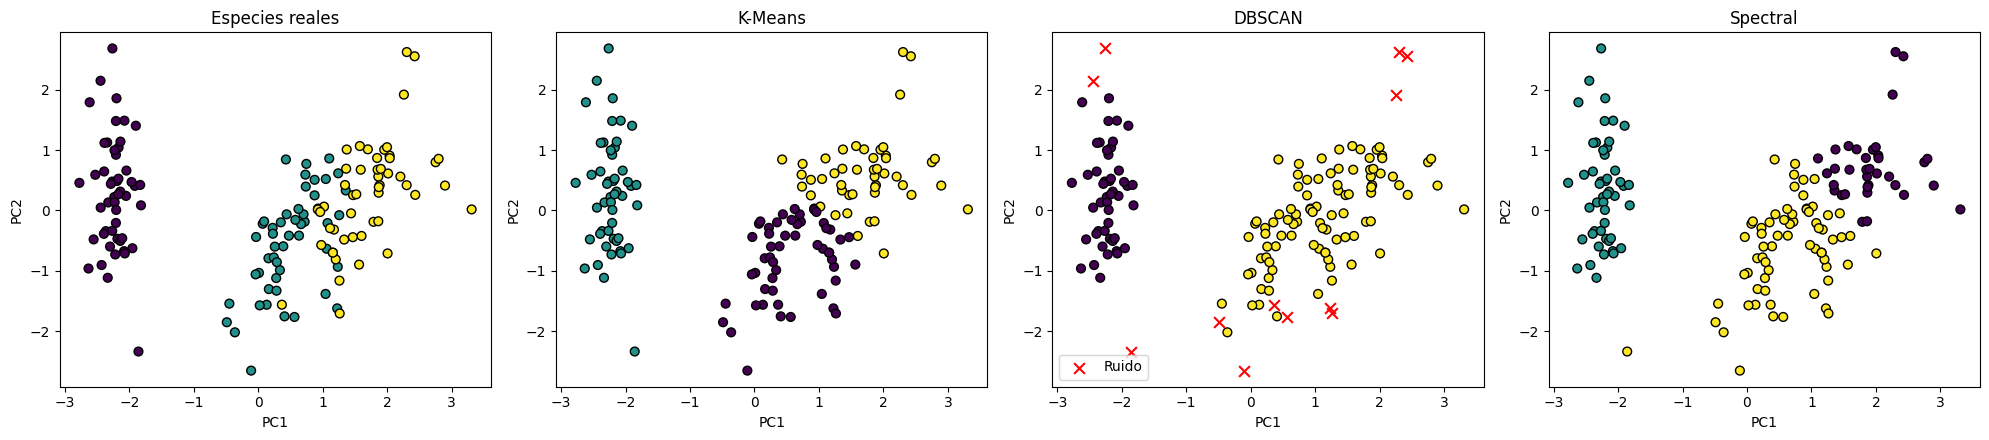

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

axes[0].scatter(X_pca[:,0], X_pca[:,1], c=y_true, cmap="viridis", edgecolor="k", s=40)
axes[0].set_title("Especies reales")

for ax, (nombre, lab) in zip(axes[1:], resultados.items()):
    ruido = lab == -1
    ax.scatter(X_pca[~ruido,0], X_pca[~ruido,1], c=lab[~ruido], cmap="viridis", edgecolor="k", s=40)
    if ruido.any():
        ax.scatter(X_pca[ruido,0], X_pca[ruido,1], c="red", marker="x", s=60, label="Ruido")
        ax.legend()
    ax.set_title(nombre)

for ax in axes:
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()

## 7. Tabla resumen y conclusiones

In [13]:
resumen = pd.concat([interna, externa], axis=1).round(3)
resumen["Nº clusters"] = [len(set(l)) - (1 if -1 in l else 0) for l in resultados.values()]
resumen["Ruido"] = [int((l == -1).sum()) for l in resultados.values()]
resumen

,Silhouette,Calinski-Harabasz,Davies-Bouldin,ARI,NMI,Mutual Info,Homogeneidad,Completitud,V-measure,Nº clusters,Ruido
K-Means,0.460,241.904,0.834,0.620,0.659,0.724,0.659,0.660,0.659,3,0
DBSCAN,0.618,305.318,0.533,0.512,0.602,0.592,0.539,0.681,0.602,2,12
Spectral,0.459,229.680,0.822,0.646,0.684,0.740,0.674,0.694,0.684,3,0


### Cómo interpretar los resultados

- **Setosa** siempre se separa perfectamente; el reto es separar **versicolor** de **virginica**, que se solapan.
- **K-Means** y **Spectral Clustering** (con *k* = 3) suelen dar resultados muy parecidos y las mejores métricas externas (ARI ≈ 0.6 y NMI ≈ 0.65–0.7).
- **DBSCAN** encuentra el número de clusters por sí mismo y obtiene el mejor silhouette (≈ 0.6), pero lo hace uniendo versicolor y virginica en un solo grupo (2 clusters) y marcando algunos puntos como ruido; por eso su ARI/NMI frente a las 3 especies es menor (≈ 0.5).
- **Métricas internas vs. externas:** la validación interna (Silhouette, CH, DB) puede preferir 2 clusters, mientras que la externa premia coincidir con las 3 especies. Esto ilustra que *un buen valor interno no siempre implica que los grupos coincidan con las categorías reales*.
- **No hay un algoritmo "mejor" universal:** la elección depende del caso de uso (¿se conoce *k*? ¿hay ruido? ¿las fronteras son lineales?), tal como indican las diapositivas.

> Los valores exactos pueden variar ligeramente según la versión de scikit-learn; lo importante es la comparación relativa.